It is important to select the required splicing that we will use, from the simulation. Essentially, determining which time interval we will extract the trajectories for constructing the motion trees.
Since the structure has already been viewed in VMD, we will now decide what time interval to use


# Creating a combined trajectory across all steps and calc rms:
gmx trjcat -f step5_*.xtc -o combinedsteps.xtc
gmx rms -s step5_1.tpr -f combinedsteps.xtc -n ca.ndx 
>output as rmsd.xvg

In [5]:
cd ./gromacs/

/media/dylan/2tb/Personal/University/Birkbeck/Mark_project/4ake/gromacs output/gromacs


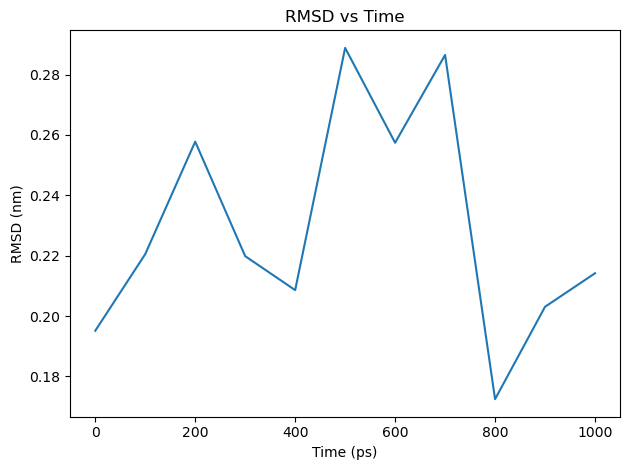

In [6]:
import matplotlib.pyplot as plt

x = []
y = []

with open("rmsd.xvg", "r") as f:
    for line in f:

        if line.startswith("#") or line.startswith("@"):
            continue
        
        cols = line.split()
        if len(cols) == 2:
            x.append(float(cols[0]))
            y.append(float(cols[1]))

plt.figure()
plt.plot(x, y)

plt.xlabel("Time (ps)")
plt.ylabel("RMSD (nm)")
plt.title("RMSD vs Time")
plt.tight_layout()
plt.show()

Due to the above graph, it appears that the fluctuations at t=400 ps+, indicate that there is some equilibrated state has been reached. Thus, that will be the time variable.


In [ ]:
# Splicing
gmx trjconv -f full.xtc -s step5_1.tpr -b 400 -o motion_tree_input_.xtc